In [ ]:
#import library yang dibutuhkan

import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/SaveRajaAmpat.csv')
df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1935587423570071582,Thu Jun 19 06:36:17 +0000 2025,0,#saveTNTN #saveTessonilo #SaveIndonesia #SaveR...,1935587423570071582,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/193558742357007...,415982172,NaN
1,1935565662837186785,Thu Jun 19 06:35:06 +0000 2025,0,Seekor gajah kecil kehilangan ibunya. Oranguta...,1935587124742627793,NaN,Ryuu531,in,NaN,0,0,0,https://x.com/undefined/status/193558712474262...,415982172,NaN
2,1935587006001910046,Thu Jun 19 06:34:38 +0000 2025,11,Semangat siang semua! #SaveRajaAmpat #Lengserk...,1935587006001910046,https://pbs.twimg.com/media/GtyWH45a4AAaDBn.jpg,NaN,in,NaN,0,6,6,https://x.com/undefined/status/193558700600191...,1292360032202272768,NaN
3,1935585135132647476,Thu Jun 19 06:27:12 +0000 2025,0,Hutan Hujan Tropis Indonesia: Warisan Dunia y...,1935585135132647476,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/193558513513264...,415982172,NaN
4,1935584083532521601,Thu Jun 19 06:23:01 +0000 2025,0,Konten2 jahat : #SaveRajaAmpat #IndonesiaGelap...,1935584083532521601,NaN,NaN,nl,NaN,0,0,0,https://x.com/undefined/status/193558408353252...,181125814,NaN


In [ ]:
print(df.columns.tolist())
print(df.dtypes)

['conversation_id_str', 'created_at', 'favorite_count', 'full_text', 'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location', 'quote_count', 'reply_count', 'retweet_count', 'tweet_url', 'user_id_str', 'username']
conversation_id_str          int64
created_at                  object
favorite_count               int64
full_text                   object
id_str                       int64
image_url                   object
in_reply_to_screen_name     object
lang                        object
location                   float64
quote_count                  int64
reply_count                  int64
retweet_count                int64
tweet_url                   object
user_id_str                  int64
username                   float64
dtype: object


In [ ]:
#pilih attribut mana saja yang akan di ambil
df = df[['full_text']]
df

,full_text
0,#saveTNTN #saveTessonilo #SaveIndonesia #SaveR...
1,Seekor gajah kecil kehilangan ibunya. Oranguta...
2,Semangat siang semua! #SaveRajaAmpat #Lengserk...
3,Hutan Hujan Tropis Indonesia: Warisan Dunia y...
4,Konten2 jahat : #SaveRajaAmpat #IndonesiaGelap...
...,...
131,Yang tak berdarah mati. Yang kekurangan darah ...
132,Aku lebih mempercayai ilmu pengetahuan akal. S...
133,guys gua cocok ko dijadiin abang please ini ho...
134,Pengelolaan Bumi oleh Manusia dan Warning Isra...


In [ ]:
df = df.drop_duplicates(subset=['full_text'],keep=False)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
full_text,0


In [ ]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # hapus mention
    text = re.sub(r'#\w+', '', text)  # hapus hashtag
    text = re.sub(r'RT[\s]+', '', text)  # hapus Retweet
    text = re.sub(r'https?://\S+', '', text)  # hapus url

    text = re.sub(r'\b\d+\.\d+\b', '', text)  # hapus angka desimal (float)
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)  # hapus karakter non alpha numeric
    # text = re.sub(r'\s+', ' ', text).


    return text

df['full_text'] = df['full_text'].apply(clean_twitter_text)

In [ ]:
df['full_text'] = df['full_text'].str.lower()
df

,full_text
0,hutan sumatra dan kalimantan bukan milik k...
1,seekor gajah kecil kehilangan ibunya orangutan...
2,semangat siang semua
3,hutan hujan tropis indonesia warisan dunia ya...
4,konten2 jahat ect
...,...
129,habis terbitlah kembali ke ibu pertiwi ace...
132,aku lebih mempercayai ilmu pengetahuan akal se...
133,guys gua cocok ko dijadiin abang please ini ho...
134,pengelolaan bumi oleh manusia dan warning isra...


In [ ]:
#normalisasi

norm = {
    'utk' : 'untuk',
    'tdk' : 'tidak',
    'sdh' : 'sudah',
    'minn' : 'admin',
    'bkl' : 'akan',
    'gk' : 'tidak',
    'trbuat' : 'terbuat',
    'dr' : 'dari',
    'yg' : 'yang',
    'pdhl' : 'padahal',
    'otw' : 'on the way',
    'skg' : 'sekarang',
    'knp' : 'kenapa',
    'boss2': 'bos',
    'jdi' : 'jadi',
    'ln' : 'luar negri',
    'nnti' : 'nanti',
    'tmbah' : 'tambah',
    'wts' : 'want to sell',
    'drpda' : 'dari pada',
    'dll' : 'dan lain lain',
    'udh' : 'sudah',
    'lg' : 'lagi',
    'kira2' : 'kira kira',
    'klo' : 'kalau',
    'gw' : 'saya',
    'ga' : 'tidak',
    'byk' : 'banyak',
    'bnyk' : 'banyak',
    'sgra' : 'segera',
    'sgr' : 'segera'
}

def normalisasi(str_text):
  for i in norm:
    str_text = str_text.replace(i,norm[i])
  return str_text
df['full_text'] = df['full_text'].apply(lambda x: normalisasi(x))
df

,full_text
0,hutan sumatra dan kalimantan bukan milik k...
1,seekor tidakjah kecil kehilantidakn ibunya ora...
2,semantidakt siang semua
3,hutan hujan tropis indonesia warisan dunia ya...
4,konten2 jahat ect
...,...
129,habis terbitlah kembali ke ibu pertiwi ace...
132,aku lebih mempercayai ilmu pengetahuan akal se...
133,guys gua cocok ko dijadiin abang please ini ho...
134,pengelolaan bumi oleh manusia dan warning isra...


In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.1 MB/s eta 0:00:00


In [ ]:
#stopword

import Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
more_stop_words = ["dan", "atau", "yang", "di", "ke", "kok"]

stop_words = StopWordRemoverFactory().get_stop_words()
stop_words.extend(more_stop_words)

new_array = ArrayDictionary(stop_words)
stop_words_remover_new = StopWordRemover(new_array)

def stopword(str_text):
  str_text = stop_words_remover_new.remove(str_text)
  return str_text

df['full_text'] = df['full_text'].apply(lambda x: stopword(x))
df.head()


,full_text
0,hutan sumatra kalimantan bukan milik saja ...
1,seekor tidakjah kecil kehilantidakn ibunya ora...
2,semantidakt siang semua
3,hutan hujan tropis indonesia warisan dunia te...
4,konten2 jahat ect


In [ ]:
#tokenize

tokenized = df['full_text'].apply(lambda x:x.split())
tokenized

,full_text
0,"[hutan, sumatra, kalimantan, bukan, milik, saj..."
1,"[seekor, tidakjah, kecil, kehilantidakn, ibuny..."
2,"[semantidakt, siang, semua]"
3,"[hutan, hujan, tropis, indonesia, warisan, dun..."
4,"[konten2, jahat, ect]"
...,...
129,"[habis, terbitlah, ke, ibu, pertiwi, aceh, nad]"
132,"[aku, lebih, mempercayai, ilmu, pengetahuan, a..."
133,"[guys, gua, cocok, ko, dijadiin, abang, please..."
134,"[pengelolaan, bumi, manusia, warning, israffas..."


In [ ]:
# !pip install translate

In [ ]:
data = pd.read_csv("/content/SaveRajaAmpat.csv", encoding = 'latin1')
data.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1935587423570071582,Thu Jun 19 06:36:17 +0000 2025,0,#saveTNTN #saveTessonilo #SaveIndonesia #SaveR...,1935587423570071582,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/193558742357007...,415982172,NaN
1,1935565662837186785,Thu Jun 19 06:35:06 +0000 2025,0,Seekor gajah kecil kehilangan ibunya. Oranguta...,1935587124742627793,NaN,Ryuu531,in,NaN,0,0,0,https://x.com/undefined/status/193558712474262...,415982172,NaN
2,1935587006001910046,Thu Jun 19 06:34:38 +0000 2025,11,Semangat siang semua! #SaveRajaAmpat #Lengserk...,1935587006001910046,https://pbs.twimg.com/media/GtyWH45a4AAaDBn.jpg,NaN,in,NaN,0,6,6,https://x.com/undefined/status/193558700600191...,1292360032202272768,NaN
3,1935585135132647476,Thu Jun 19 06:27:12 +0000 2025,0,Hutan Hujan Tropis Indonesia: Warisan Dunia y...,1935585135132647476,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/193558513513264...,415982172,NaN
4,1935584083532521601,Thu Jun 19 06:23:01 +0000 2025,0,Konten2 jahat : #SaveRajaAmpat #IndonesiaGelap...,1935584083532521601,NaN,NaN,nl,NaN,0,0,0,https://x.com/undefined/status/193558408353252...,181125814,NaN


In [ ]:
# from translate import Translator

# def convert_eng(tweet):
#   # Convert tweet to string to ensure 'expandtabs' works
#   tweet = str(tweet)
#   translator = Translator(to_lang='en', from_lang='id')
#   translation = translator.translate(tweet)
#   return translation

# data['tweet_english'] = data['full_text'].apply(convert_eng)
# data.to_csv("/content/preprocessing/hasil-bahasainggris-persib.csv")

In [ ]:
# data = pd.read_csv('/content/preprocessing/hasil-bahasainggris-persib.csv',index_col=0)
# data.head()

In [ ]:
!pip install googletrans==4.0.0-rc1

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 3.4 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=25db61e7a39efadb5444a24d2708f98ba644a67702cc92494f1b758613162f44
  Stored in directory: /root/.cache/pip/wheels/39/17/6f/66a045ea3d168826074691b4b787b8f324d3f646d755443fda
Successfully built googletrans
  Attempting uninstall: hyperframe
    Found existing installation: hyperframe 6.1.0
    Uninstalling hyperfram

In [ ]:
from googletrans import Translator

def convert_eng(tweet):
    # Convert tweet to string untuk menghindari error saat ada data float
    tweet = str(tweet)
    translator = Translator()
    # Menerjemahkan teks dari Bahasa Indonesia ke Bahasa Inggris
    translation = translator.translate(tweet, src='id', dest='en')
    return translation.text

# Menerapkan fungsi pada kolom 'full_text'
data['tweet_english'] = data['full_text'].apply(convert_eng)

# Menyimpan hasil ke file CSV
data.to_csv("/content/SaveRajaAmpat.csv", index=False)


In [ ]:
data = pd.read_csv('/content/SaveRajaAmpat.csv',index_col=0)
data.head()

,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,tweet_english
conversation_id_str,,,,,,,,,,,,,,,
1935587423570071582,Thu Jun 19 06:36:17 +0000 2025,0,#saveTNTN #saveTessonilo #SaveIndonesia #SaveR...,1935587423570071582,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/193558742357007...,415982172,NaN,#SaveTntn #SaveTessonilo #saveindonesia #saver...
1935565662837186785,Thu Jun 19 06:35:06 +0000 2025,0,Seekor gajah kecil kehilangan ibunya. Oranguta...,1935587124742627793,NaN,Ryuu531,in,NaN,0,0,0,https://x.com/undefined/status/193558712474262...,415982172,NaN,A little elephant loses his mother.Orangutans ...
1935587006001910046,Thu Jun 19 06:34:38 +0000 2025,11,Semangat siang semua! #SaveRajaAmpat #Lengserk...,1935587006001910046,https://pbs.twimg.com/media/GtyWH45a4AAaDBn.jpg,NaN,in,NaN,0,6,6,https://x.com/undefined/status/193558700600191...,1292360032202272768,NaN,All afternoon spirit!#Saverajaampat #lengserka...
1935585135132647476,Thu Jun 19 06:27:12 +0000 2025,0,Hutan Hujan Tropis Indonesia: Warisan Dunia y...,1935585135132647476,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/193558513513264...,415982172,NaN,Indonesian Tropical Rain Forest: World Heritag...
1935584083532521601,Thu Jun 19 06:23:01 +0000 2025,0,Konten2 jahat : #SaveRajaAmpat #IndonesiaGelap...,1935584083532521601,NaN,NaN,nl,NaN,0,0,0,https://x.com/undefined/status/193558408353252...,181125814,NaN,Evil content: #Averajaampat #IndonesiaGelap ECT


In [ ]:
!pip install tweet-preprocessor
!pip install textblob
!pip install wordcloud
!pip install nltk

In [ ]:
import preprocessor as p
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
#proses labeling

# Menggunakan Text Blob
data_tweet = list(data['tweet_english'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
  analysis = TextBlob(tweet)
  polaritas += analysis.polarity

  if analysis.sentiment.polarity > 0.0:
      total_positif += 1
      status.append('positif')
  elif analysis.sentiment.polarity == 0.0:
      total_netral += 1
      status.append('netral')
  else:
      total_negatif +=1
      status.append('Negatif')

  total += 1

print(f'hasil analisis data:\nPositif = {total_positif}\nNetral ={total_netral}\nNegatif = {total_negatif}')
print(f'\nTotal Data: {total}')

hasil analisis data:
Positif = 53
Netral =62
Negatif = 21

Total Data: 136


In [ ]:
#tampilkan data
data['klasifikasi'] = status
data

,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,tweet_english,klasifikasi
conversation_id_str,,,,,,,,,,,,,,,,
1935587423570071582,Thu Jun 19 06:36:17 +0000 2025,0,#saveTNTN #saveTessonilo #SaveIndonesia #SaveR...,1935587423570071582,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/193558742357007...,415982172,NaN,#SaveTntn #SaveTessonilo #saveindonesia #saver...,netral
1935565662837186785,Thu Jun 19 06:35:06 +0000 2025,0,Seekor gajah kecil kehilangan ibunya. Oranguta...,1935587124742627793,NaN,Ryuu531,in,NaN,0,0,0,https://x.com/undefined/status/193558712474262...,415982172,NaN,A little elephant loses his mother.Orangutans ...,Negatif
1935587006001910046,Thu Jun 19 06:34:38 +0000 2025,11,Semangat siang semua! #SaveRajaAmpat #Lengserk...,1935587006001910046,https://pbs.twimg.com/media/GtyWH45a4AAaDBn.jpg,NaN,in,NaN,0,6,6,https://x.com/undefined/status/193558700600191...,1292360032202272768,NaN,All afternoon spirit!#Saverajaampat #lengserka...,netral
1935585135132647476,Thu Jun 19 06:27:12 +0000 2025,0,Hutan Hujan Tropis Indonesia: Warisan Dunia y...,1935585135132647476,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/193558513513264...,415982172,NaN,Indonesian Tropical Rain Forest: World Heritag...,positif
1935584083532521601,Thu Jun 19 06:23:01 +0000 2025,0,Konten2 jahat : #SaveRajaAmpat #IndonesiaGelap...,1935584083532521601,NaN,NaN,nl,NaN,0,0,0,https://x.com/undefined/status/193558408353252...,181125814,NaN,Evil content: #Averajaampat #IndonesiaGelap ECT,Negatif
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1935004531848511710,Tue Jun 17 16:00:05 +0000 2025,0,Yang tak berdarah mati. Yang kekurangan darah ...,1935004531848511710,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/193500453184851...,1891685698157281282,NaN,Which is not bleeding dead.Which lacks weak bl...,Negatif
1935004526765056415,Tue Jun 17 16:00:04 +0000 2025,1,Aku lebih mempercayai ilmu pengetahuan akal. S...,1935004526765056415,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/193500452676505...,1897487771230724101,NaN,I trust more the science of reason.At least th...,positif
1935003077427478836,Tue Jun 17 15:54:18 +0000 2025,0,guys gua cocok ko dijadiin abang please ini ho...,1935003077427478836,NaN,NaN,in,NaN,0,1,0,https://x.com/undefined/status/193500307742747...,725490730299334656,NaN,Guys I match how to be a brother please honest...,positif


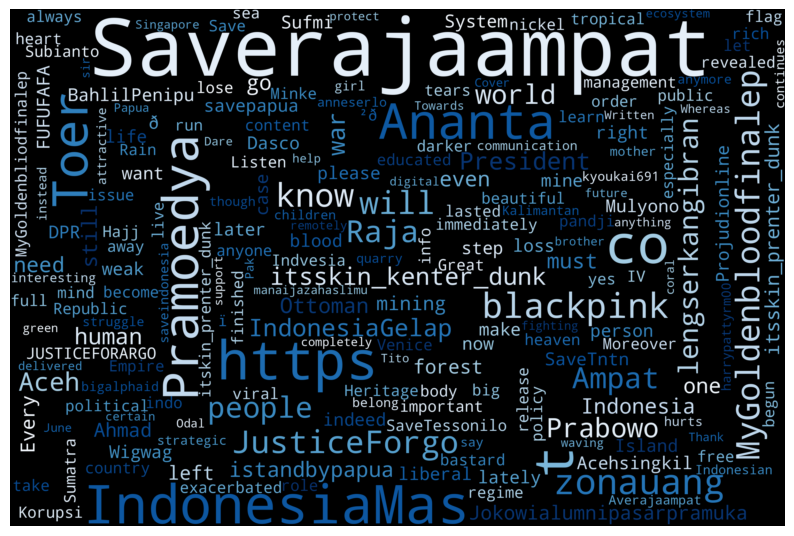

In [ ]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
  plt.figure(figsize=(10,8))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.show()

# Assuming 'tweet_english' or '0' is the correct column name
# Replace 'tweet_english' with the actual name if different or use data.columns[0] if it is first column.
all_words = ' '.join([tweets for tweets in data['tweet_english']])
#all_words = ' '.join([tweets for tweets in data[data.columns[0]]])

wordcloud = WordCloud(
    width = 3000,
    height = 2000,
    random_state = 3,
    background_color='black',
    colormap="Blues_r",
    collocations = False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(wordcloud)

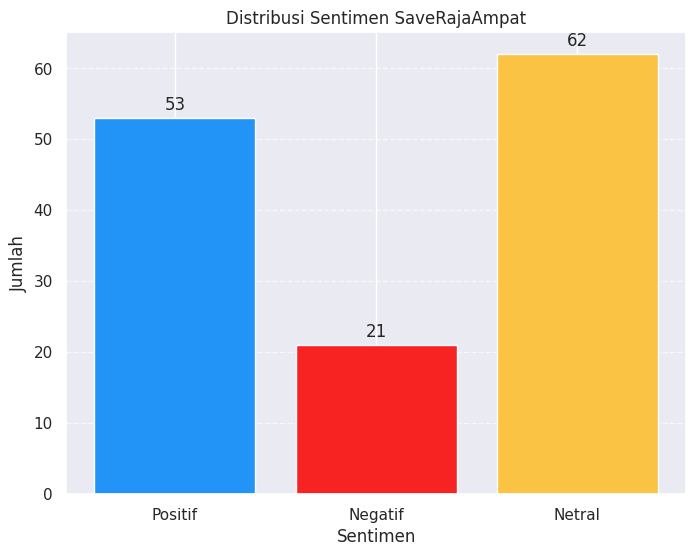

In [ ]:
#visualisasi Sentimen

import seaborn as sns

sns.set_theme()

labels = ['Positif', 'Negatif', 'Netral']
counts = [total_positif, total_negatif, total_netral]

def show_bar_chart(labels,counts, title):
  fig, ax = plt.subplots(figsize=(8,6))
  bars = ax.bar(labels,counts,color=['#2394f7','#f72323','#fac343'])

  for bar, count in zip(bars, counts):
      height = bar.get_height()
      ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width()/2, height),
                  xytext=(0,3),
                  textcoords='offset points',
                  ha='center',va='bottom')
  ax.grid(axis='y', linestyle='--',alpha=0.7)

  ax.set_xlabel('Sentimen')
  ax.set_ylabel('Jumlah')
  ax.set_title(title)

  plt.show()

show_bar_chart(labels,counts,'Distribusi Sentimen SaveRajaAmpat')